In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, LeakyReLU, Reshape, Input
from tensorflow.keras.datasets import mnist

### Loading + Preprocessing of Data

In [12]:
(train_x, _), (_, _) = mnist.load_data()

# Normalize to [-1, 1]
train_x = (train_x - 127.5) / 127.5

# Reshape
train_x = train_x.reshape(-1, 28, 28, 1)

print(train_x.shape)

(60000, 28, 28, 1)


### Generator

In [13]:
generator = Sequential([
    Input(shape=(100,)),

    Dense(512),
    LeakyReLU(negative_slope=0.2),
    BatchNormalization(momentum=0.8),

    Dense(256),
    LeakyReLU(negative_slope=0.2),
    BatchNormalization(momentum=0.8),

    Dense(128),
    LeakyReLU(negative_slope=0.2),
    BatchNormalization(momentum=0.8),

    Dense(784, activation='tanh'),
    Reshape((28, 28, 1))
])

### Discriminator

In [14]:
discriminator = Sequential([
    Flatten(input_shape=(28,28,1)),

    Dense(256),
    LeakyReLU(negative_slope=0.2),
    Dropout(0.5),

    Dense(128),
    LeakyReLU(negative_slope=0.2),
    Dropout(0.5),

    Dense(64),
    LeakyReLU(negative_slope=0.2),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer='adam', loss='binary_crossentropy')

### GAN Model

In [15]:
discriminator.trainable = False

gan = Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

### Training Loop

Epoch 1


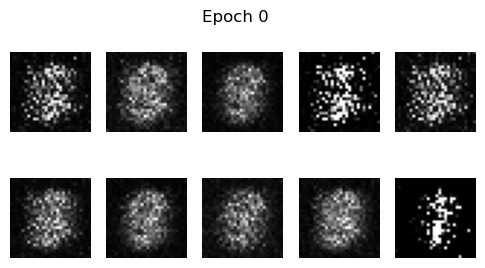

Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6


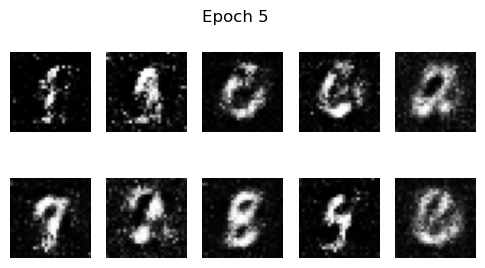

Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11


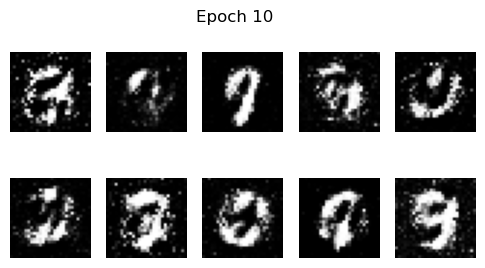

Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16


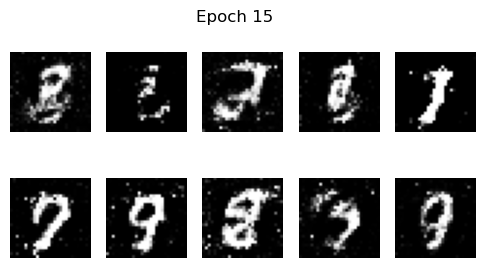

Epoch 17
Epoch 18
Epoch 19
Epoch 20


In [16]:
epochs = 20   # increase for better digits
batch_size = 100
noise_dim = 100

for epoch in range(epochs):

    print(f"Epoch {epoch+1}")

    for i in range(train_x.shape[0] // batch_size):

        # Generate fake images
        noise = np.random.normal(0,1,(batch_size, noise_dim))
        fake = generator.predict(noise, verbose=0)

        # Real images
        real = train_x[i*batch_size:(i+1)*batch_size]

        # Labels
        y_real = np.ones((batch_size,1))
        y_fake = np.zeros((batch_size,1))

        # Train Discriminator
        discriminator.trainable = True
        discriminator.train_on_batch(real, y_real)
        discriminator.train_on_batch(fake, y_fake)

        # Train Generator
        noise = np.random.normal(0,1,(batch_size, noise_dim))
        discriminator.trainable = False
        gan.train_on_batch(noise, y_real)

    # Show generated images every 5 epochs
    if epoch % 5 == 0:
        samples = 10
        noise = np.random.normal(0,1,(samples, noise_dim))
        gen = generator.predict(noise, verbose=0)

        plt.figure(figsize=(6,3))
        for k in range(samples):
            plt.subplot(2,5,k+1)
            plt.imshow(gen[k].reshape(28,28), cmap='gray')
            plt.axis('off')
        plt.suptitle(f"Epoch {epoch}")
        plt.show()

### Final Output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


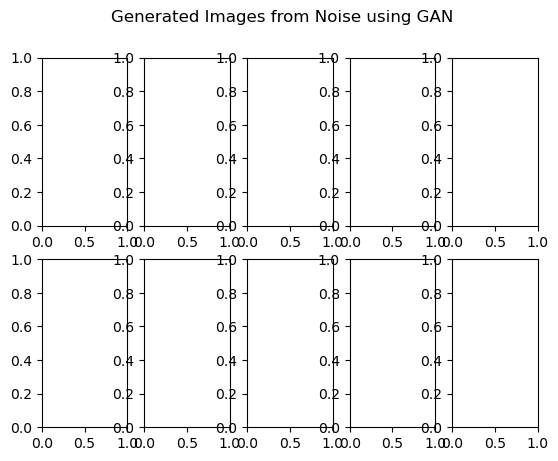

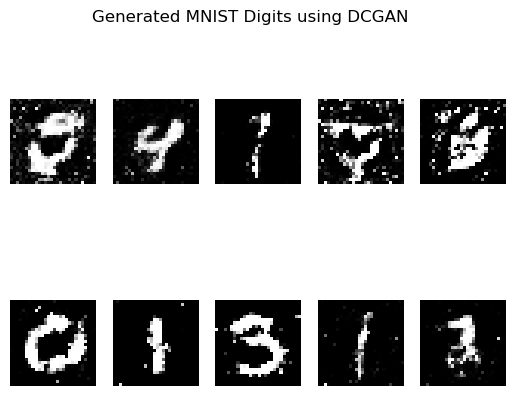

In [17]:
noise = np.random.normal(0,1,(10,100))
gen = generator.predict(noise)

fig, ax = plt.subplots(2,5)
fig.suptitle('Generated Images from Noise using GAN')
noise = np.random.normal(0,1,(10,100))
gen = generator.predict(noise)

fig, ax = plt.subplots(2,5)
fig.suptitle('Generated MNIST Digits using DCGAN')

idx = 0
for i in range(2):
    for j in range(5):
        ax[i,j].imshow(gen[idx].reshape(28,28), cmap='gray')
        ax[i,j].axis('off')
        idx += 1

plt.show()
idx = 0
for i in range(2):
    for j in range(5):
        ax[i,j].imshow(gen[idx].reshape(28,28), cmap='gray')
        ax[i,j].axis('off')
        idx += 1

plt.show()